<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Models_II.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Models_II.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

# Preparation

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [2]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [3]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [4]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [5]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [6]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [7]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`

...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a dictionary of performance metrics as values.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

I'll be using the `shelve` module to save the dictionary. The dictionary is loaded in the code cell below and given the name `models_performance`. 

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from life_saving_tools import Notification
from sklearn.model_selection import GridSearchCV
import shelve
n = Notification.Notification()
params = {}

def load_performance_dict(file = 'models_performance.shelve'):
    """
    This function loads the performance of a model from the `model_performance` \\
        dictionary.

    Parameters
    ----------
    model_name : string
        the name of the model to load from the `model_performance` dictionary

    Returns
    -------
    model_performance : dictionary
    """
    shelve_file = shelve.open(file)

    try:
        models_performance = shelve_file['models_performance']
    except:
        models_performance = {}

    shelve_file.close()
    return models_performance

models_performance = load_performance_dict()

def save_performance_dict(file = 'models_performance.shelve', dict = models_performance):
    """
    This function saves the model_performance dictionary to a shelve file.

    Parameters
    ----------
    file : string
        the name of the shelve file to save the dictionary to

    Returns
    -------
    None
    """
    shelve_file = shelve.open(file)
    shelve_file['models_performance'] = models_performance
    shelve_file.close()

def perform_grid_search(model, params = params, X= X_train, y=y_train, 
    text = False, play = True, cv = 5, scoring = 'roc_auc', **kwargs):
    """
    Performs grid serach on the model and returns the best model with parameters.

    Parameters
    ----------
    model : sklearn model

    X : training data
        defualt is X_train

    y : target data
        defualt is y_train

    params : dictionary
        the parameters to search over
        defualt is params

    text : boolean
        if True, a notification is sent to whatsapp
        defualt is False
    
    play : boolean
        if True, music is played
        defualt is True

    cv : number of folds for cross validation
        defualt is 5

    scoring : scoring metric
        defualt is 'roc_auc'

    verbose : verbosity level
        defualt is 1

    Returns
    -------
    grid_search : sklearn GridSearchCV object
    """
    grid = GridSearchCV(model, params, cv=cv, scoring=scoring, **kwargs)
    grid.fit(X, y)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_
    message = f"""Following is the best model and its parameters:\n\
Best Model:\n{best_estimator}\nBest params:\
\n{best_params}\nBest score: {best_score}"""

    if text:
        n.send_whatsapp_text(message)
    
    if play:
        n.play_n_stop()
    print(message)
    return grid

def visualize_model(model, features = X_test, target = y_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = model.predict(features)
    
    #Printing the classification report
    print(classification_report(target, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None, final = False, X = X_test, y = y_test):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    model_name : string
        the name of the model to store as a key in the `model_performance` dictionary

    final : boolean
        if True, the scores are added to the `model_performance` dictionary as well

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X)

    #Getting the metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

    if final:
    #Adding the metrics to the model_performance dictionary
        if model_name is None:
            model_name = type(model).__name__

        models_performance[model_name] = {
                'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
        save_performance_dict()
        return models_performance[model_name]
    else:
        return {'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# Boosting Models

## GradientBoostingClassifier

### Default Parameters

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_base = GradientBoostingClassifier(random_state=101)
gbc_base.fit(X_train, y_train)

GradientBoostingClassifier(random_state=101)

In [ ]:
evaluate_model(gbc_base, 'gbc_base', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7640449438202247,
 'recall': 0.7640449438202247,
 'f1': 0.7640449438202248,
 'roc_auc': 0.8036642629548886}

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       134
           1       0.76      0.76      0.76        89

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



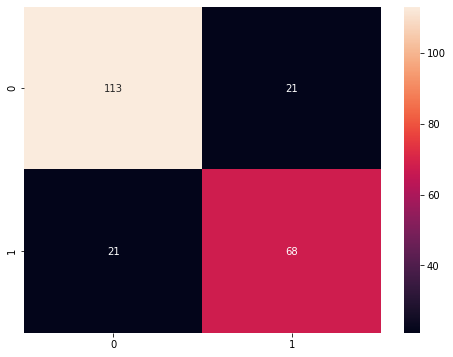

In [ ]:
visualize_model(gbc_base)

### Searching for the best parameters

The GradientBoostingClassifier has the following parameters:
* `n_estimators`: int, default 100. The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.
* `learning_rate`: float, default 0.1. Learning rate shrinks the contribution of each tree by `learning_rate`. There is a trade-off between learning_rate and n_estimators.
* `criterion`: {‘friedman_mse’, ‘mse’, ‘mae’}, default ‘friedman_mse’. The function to measure the quality of a split.
* `loss`: {‘deviance’, ‘exponential’}, default ‘deviance’. The loss function to use when doing regression.
* `max_depth`: int, default 3. Maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. Tune this parameter for best performance; the best value depends on the interaction of the input variables.
* `min_samples_split`: int, default 2. The minimum number of samples required to split an internal node.
* `min_samples_leaf`: int, default 1. The minimum number of samples required to be at a leaf node.
* `min_impurity_decrease`: float, default 0.0. A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
* `max_features`: int, float, string or None, default ‘auto’. The number of features to consider when looking for the best split:
    - If int, then consider `max_features` features at each split.
    - If float, then `max_features` is a percentage and a random number of features are considered at each split.
    - If “auto”, then `max_features=sqrt(n_features)`.
    - If “sqrt”, then `max_features=sqrt(n_features)`.
    - If “log2”, then `max_features=log2(n_features)`.
    - If None, then `max_features=n_features`.


In [ ]:
all_params = {'n_estimators': [40, 50, 60,70,80],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'criterion': ['friedman_mse', 'mse', 'mae'],
    'loss': ['deviance', 'exponential'],
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'min_impurity_decrease': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
}

Since there are tons of hyperparameters to tune, we'll just search a subset of them.

In [ ]:
params = {'n_estimators': [40, 50, 60,70,80],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'criterion': ['friedman_mse', 'mse', 'mae'],
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto'],
}

gbc_base = GradientBoostingClassifier(random_state=101)
grid_10 = perform_grid_search(gbc_base, params, text = True, play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 16200 candidates, totalling 48600 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  48 tasks      | elapsed:    5.6s
[Parallel(n_jobs=4)]: Done 644 tasks      | elapsed:   16.2s
[Parallel(n_jobs=4)]: Done 1644 tasks      | elapsed:   50.4s
[Parallel(n_jobs=4)]: Done 2024 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 2474 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 3024 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 4080 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 5580 tasks      | elapsed:  4.0min
[Parallel(n_jobs=4)]: Done 6752 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done 8652 tasks      | elapsed:  6.5min
[Parallel(n_jobs=4)]: Done 10216 tasks      | elapsed:  8.0min
[Parallel(n_jobs=4)]: Done 12228 tasks      | elapsed:  9.9min
  0%|          | 0/5 [15:40<?, ?it/s]
[Parallel(n_jobs=4)]: Done 14710 tasks      | elapsed: 11.8min
[Parallel(n_jobs=4)]: Done 16060 tasks      | elapsed: 13.4min
[Parallel(n_jobs=

SMa8f34fe583214ed0be89dad476ea1021
Following is the best model and its parameters:
    Best Model:
GradientBoostingClassifier(learning_rate=0.2, max_depth=2, max_features='auto',
                           min_samples_leaf=4, min_samples_split=12,
                           n_estimators=40, random_state=101)
Best params:
    
{'criterion': 'friedman_mse', 'learning_rate': 0.2, 'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 40}
Best score: 0.8717132736387921


In [ ]:
params = {'n_estimators': [35,40,45],
    'learning_rate': [0.15, 0.2, 0.25],
    'criterion': ['friedman_mse'],
    'max_depth': [1, 2, 3],
    'min_samples_split': [3, 4, 5],
    'min_samples_leaf': [3, 4, 5],
    'max_features': ['auto'],
}

gbc_base = GradientBoostingClassifier(random_state=101)
grid_11 = perform_grid_search(gbc_base, params, text = False, play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 128 tasks      | elapsed:    1.8s


Following is the best model and its parameters:
    Best Model:
GradientBoostingClassifier(learning_rate=0.2, max_features='auto',
                           min_samples_leaf=3, min_samples_split=3,
                           n_estimators=35, random_state=101)
Best params:
    
{'criterion': 'friedman_mse', 'learning_rate': 0.2, 'max_depth': 3, 'max_features': 'auto', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best score: 0.874669762424137


[Parallel(n_jobs=4)]: Done 729 out of 729 | elapsed:   11.4s finished


In [ ]:
evaluate_model(grid_10.best_estimator_)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

In [ ]:
evaluate_model(grid_11.best_estimator_)

{'accuracy': 0.8116591928251121,
 'precision': 0.7640449438202247,
 'recall': 0.7640449438202247,
 'f1': 0.7640449438202248,
 'roc_auc': 0.8036642629548886}

No improvement. Best model is:

In [ ]:
gbc_final = grid_10.best_estimator_
evaluate_model(gbc_final, 'gbc_final', final = True)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       134
           1       0.79      0.80      0.79        89

    accuracy                           0.83       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.83      0.83      0.83       223



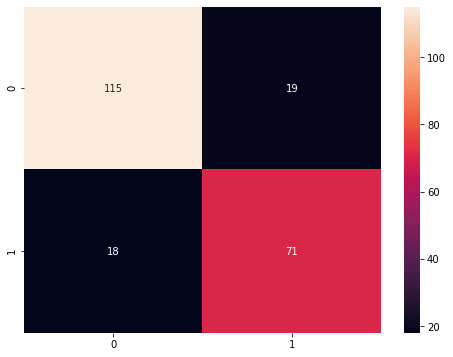

In [ ]:
visualize_model(gbc_final)

In [ ]:
pd.DataFrame(models_performance).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.816143,0.785714,0.741573,0.763006,0.803622
dt_base,0.780269,0.708333,0.764045,0.735135,0.777545
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.766667,0.775281,0.770950,0.809282
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


## XGBClassifier

### Default Parameters

In [24]:
from xgboost import XGBClassifier
xgb_base = XGBClassifier(use_label_encoder=False)
xgb_base.fit(X_train, y_train)

[16:42:33] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [26]:
evaluate_model(xgb_base, 'sgb_base', final=True)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

In [27]:
pd.DataFrame(models_performance).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.816143,0.785714,0.741573,0.763006,0.803622
dt_base,0.780269,0.708333,0.764045,0.735135,0.777545
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.766667,0.775281,0.770950,0.809282
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


### Searching for best parameters

The XGBClassifier has almost same parameters as the `GradientBoostingClassifier`. We'll be using this. Some different parameters are:
* `booster`: {‘gbtree’, ‘gblinear’, ‘dart’}, default ‘gbtree’. The tree algorithm used.
* `min_child_weight`: int, default 1. Minimum sum of instance weight(hessian) needed in a child.
* `max_delta_step`: int, default 0. Maximum delta step we allow each tree’s weight estimation to be.
* `subsample`: float, default 1.0. Subsample ratio of the training instances.
* `colsample_bytree`: float, default 1.0. Subsample ratio of columns when constructing each tree.
* `colsample_bylevel`: float, default 1.0. Subsample ratio of columns for each split, in each level.
* `gamma`: float, default 0.0. Minimum loss reduction required to make a further partition on a leaf node of the tree.
* `reg_alpha`: float, default 0.0. L1 regularization term on weights.
* `reg_lambda`: float, default 1.0. L2 regularization term on weights.


Since the hyperparameter space is huge, we'll be using a subset of them.

In [ ]:
params = {'n_estimators': [40, 50, 60,70,80],
    'learning_rate': [0.1, 0.2, 0.3, 0.4],
    'max_depth': [2, 4, 6, 8, 10],
    'min_child_weight': [1, 2, 3, 4],
    'gamma': [0.0, 0.3, 0.6, 0.9],
    'reg_alpha': [0.0, 0.3, 0.6, 0.9],
    'reg_lambda': [0.0, 0.3, 0.6, 0.9],
    'subsample': [0.6, 0.7, 0.8, 0.9],
}

gbc_base = XGBClassifier(random_state=101)
grid_10 = perform_grid_search(gbc_base, params, text = True, play = False, verbose=1, cv = 3, n_jobs = 4)